# DevOps

In [ ]:
pip install azure-devops -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.1/207.1 kB 14.4 MB/s eta 0:00:00


In [ ]:
from azure.devops.connection import Connection
from msrest.authentication import BasicAuthentication
from rich import print as rprint
from google.colab import userdata

organization_url = 'https://dev.azure.com/genai-labs'  # Replace with your organization URL
personal_access_token = userdata.get('DEV_AZURE_DIEGO_ACCESS')

credentials = BasicAuthentication('', personal_access_token)
connection = Connection(base_url=organization_url, creds=credentials)

In [ ]:
core_client = connection.clients.get_core_client()
projects = core_client.get_projects()
work_client = connection.clients.get_work_client()
wit_client = connection.clients.get_work_item_tracking_client()
git_client = connection.clients.get_git_client()

In [ ]:
for project in projects:
    repos = git_client.get_repositories(project.id)
    for repo in repos:
        rprint(f"{project.name=}, {repo.name=}")

project.name='agentictime', repo.name='agentictime'

In [ ]:
repo.id, repo.name, repo.size, repo.url

('bc790941-f32e-4cc0-b86f-bd617653cd2d',
 'agentictime',
 2920,
 'https://dev.azure.com/genai-labs/453fa0e0-d8b6-4dea-882f-bba4d94ab062/_apis/git/repositories/bc790941-f32e-4cc0-b86f-bd617653cd2d')

In [ ]:
for stream_content in git_client.get_item_content(repo.id,"README.md"):
    print( stream_content )

b'# Introduction \r\nTODO: Give a short introduction of your project. Let this section explain the objectives or the motivation behind this project. \r\n\r\n# Getting Started\r\nTODO: Guide users through getting your code up and running on their own system. In this section you can talk about:\r\n1.\tInstallation process\r\n2.\tSoftware dependencies\r\n3.\tLatest releases\r\n4.\tAPI references\r\n\r\n# Build and Test\r\nTODO: Describe and show how to build your code and run the tests. \r\n\r\n# Contribute\r\nTODO: Explain how other users and developers can contribute to make your code better. \r\n\r\nIf you want to learn more about creating good readme files then refer the following [guidelines](https://docs.microsoft.com/en-us/azure/devops/repos/git/create-a-readme?view=azure-devops). You can also seek inspiration from the below readme files:\r\n- [ASP.NET Core](https://github.com/aspnet/Home)\r\n- [Visual Studio Code](https://github.com/Microsoft/vscode)\r\n- [Chakra Core](https://git

In [ ]:
for content in git_client.get_item_text(repo.id,"README.md"):
    print(content)

b'# Introduction \r\nTODO: Give a short introduction of your project. Let this section explain the objectives or the motivation behind this project. \r\n\r\n# Getting Started\r\nTODO: Guide users through getting your code up and running on their own system. In this section you can talk about:\r\n1.\tInstallation process\r\n2.\tSoftware dependencies\r\n3.\tLatest releases\r\n4.\tAPI references\r\n\r\n# Build and Test\r\nTODO: Describe and show how to build your code and run the tests. \r\n\r\n# Contribute\r\nTODO: Explain how other users and developers can contribute to make your code better. \r\n\r\nIf you want to learn more about creating good readme files then refer the following [guidelines](https://docs.microsoft.com/en-us/azure/devops/repos/git/create-a-readme?view=azure-devops). You can also seek inspiration from the below readme files:\r\n- [ASP.NET Core](https://github.com/aspnet/Home)\r\n- [Visual Studio Code](https://github.com/Microsoft/vscode)\r\n- [Chakra Core](https://git

In [ ]:
for content in git_client.get_item_text(repo.id,".gitignore"):
    print(content)

b"# Byte-compiled / optimized / DLL files\n__pycache__/\n*.py[cod]\n*$py.class\n\n# C extensions\n*.so\n\n# Distribution / packaging\n.Python\nbuild/\ndevelop-eggs/\ndist/\ndownloads/\neggs/\n.eggs/\nlib/\nlib64/\nparts/\nsdist/\nvar/\nwheels/\nshare/python-wheels/\n*.egg-info/\n.installed.cfg\n*.egg\nMANIFEST\n\n# PyInstaller\n#  Usually these files are written by a python script from a template\n#  before PyInstaller builds the exe, so as to inject date/other infos into it.\n*.manifest\n*.spec\n\n# Installer logs\npip-log.txt\npip-delete-this-directory.txt\n\n# Unit test / coverage reports\nhtmlcov/\n.tox/\n.nox/\n.coverage\n.coverage.*\n.cache\nnosetests.xml\ncoverage.xml\n*.cover\n*.py,cover\n.hypothesis/\n.pytest_cache/\ncover/\n\n# Translations\n*.mo\n*.pot\n\n# Django stuff:\n*.log\nlocal_settings.py\ndb.sqlite3\ndb.sqlite3-journal\n\n# Flask stuff:\ninstance/\n.webassets-cache\n\n# Scrapy stuff:\n.scrapy\n\n# Sphinx documentation\ndocs/_build/\n\n# PyBuilder\n.pybuilder/\ntarge

In [ ]:
zip = git_client.get_item_zip(repo.id, "/")
with open(repo.name + ".zip", "wb") as f:
    for it in zip:
        f.write(it)

In [ ]:
search_criteria = None
for commit in git_client.get_commits(repo.id, search_criteria):
    print(f'{commit.comment=}')
    print(f'{commit.commit_id=}')
    print(f'{commit.committer.email=}')
    print(f'{commit.remote_url=}')
    print(f'{commit.change_counts=}')
    for change in git_client.get_changes(commit.commit_id, repo.id).changes:
        print(f"\t{change['changeType']=} {change['item']['path']=}")

commit.comment='Merge pull request 1 from config_env into main'
commit.commit_id='cfab6af06724b66371c7fc445a77223fe690d6b1'
commit.committer.email='DiegoS@mn3q.onmicrosoft.com'
commit.remote_url='https://dev.azure.com/genai-labs/agentictime/_git/agentictime/commit/cfab6af06724b66371c7fc445a77223fe690d6b1'
commit.change_counts={'Add': 2, 'Edit': 0, 'Delete': 0}
	change['changeType']='add' change['item']['path']='/.env.template'
	change['changeType']='add' change['item']['path']='/config.py'
commit.comment='Add environment configuration files for Azure, Neo4j, and MongoDB'
commit.commit_id='0a20cfa502c88b8d3dcb638bb290801afba6ca09'
commit.committer.email='DiegoS@mn3q.onmicrosoft.com'
commit.remote_url='https://dev.azure.com/genai-labs/agentictime/_git/agentictime/commit/0a20cfa502c88b8d3dcb638bb290801afba6ca09'
commit.change_counts={'Add': 2, 'Edit': 0, 'Delete': 0}
	change['changeType']='add' change['item']['path']='/.env.template'
	change['changeType']='add' change['item']['path']='/co

In [ ]:
from IPython.display import display, Markdown
search_criteria = None
for pr in git_client.get_pull_requests(repo.id, search_criteria):
    git_client.create_pull_request
    print(f'{pr.status=}')
    print(f'{pr.title=}')
    print(f'{pr.work_item_refs=}')
    print(f'{pr.commits=}')
    display(Markdown(f'{pr.description}'))
    print(f'{pr.pull_request_id=}')
    print(f'{pr.url=}')
    print(f'{pr.created_by.display_name=}')
    print(f'{pr.creation_date=}')
    print(f'{pr.last_merge_commit.commit_id=}:')
    print(f'{"="*20} <CHANGES> {"="*20}')
    for change in git_client.get_changes(pr.last_merge_commit.commit_id, repo.id).changes:
        print(f"\t{change['changeType']=} {change['item']['path']=}")
    print(f'{"="*20} </CHANGES> {"="*20}')
    print(f'{"-"*20} <WORK_ITEMS> {"="*20}')
    for work_item in git_client.get_pull_request_work_item_refs(repo.id, pr.pull_request_id):
        print(f"{work_item.id}, {work_item.url}")
        for work_item in wit_client.get_work_items(ids=[work_item.id]):
            rprint(f"ID: {work_item.id=}")
            rprint(f"{work_item.fields['System.Title']=}")
            rprint(f"{work_item.fields['System.State']=}")
            rprint(f"Reason: {work_item.fields['System.Reason']}")
            rprint(f"Area: {work_item.fields['System.AreaPath']}")
            rprint(f"Iteration: {work_item.fields['System.IterationPath']}")
            rprint(f"Type: {work_item.fields['System.WorkItemType']}")
            rprint(f"Priority: {work_item.fields['Microsoft.VSTS.Common.Priority']}")

            assigned_to = work_item.fields.get('System.AssignedTo')
            if assigned_to:
                rprint(f"Assigned To: {assigned_to['displayName']}, Profile Link: {assigned_to['url']}")

            activated_date = work_item.fields.get('Microsoft.VSTS.Common.ActivatedDate')
            if activated_date:
                rprint(f"Created Date: {work_item.fields['System.CreatedDate']}, Changed Date: {work_item.fields['System.ChangedDate']}, Activated Date: {activated_date}")

            rprint(f"{work_item.fields['System.CommentCount']=}")
    print(f'{"-"*20} </WORK_ITEMS> {"="*20}')


pr.status='active'
pr.title='[Epic 9] Add environment configuration files for Azure, Neo4j, and MongoDB'
pr.work_item_refs=None
pr.commits=None


Tasks are done:
- [x] Add environment configuration files for Azure
- [x] Add environment configuration files for Neo4j
- [x] Add environment configuration files for MongoDB

pr.pull_request_id=1
pr.url='https://dev.azure.com/genai-labs/453fa0e0-d8b6-4dea-882f-bba4d94ab062/_apis/git/repositories/bc790941-f32e-4cc0-b86f-bd617653cd2d/pullRequests/1'
pr.created_by.display_name='Diego Siciliani'
pr.creation_date=datetime.datetime(2025, 4, 7, 18, 53, 28, 862252, tzinfo=<isodate.tzinfo.Utc object at 0x7c567c122c50>)
pr.last_merge_commit.commit_id='cfab6af06724b66371c7fc445a77223fe690d6b1':
==================== <CHANGES> ====================
	change['changeType']='add' change['item']['path']='/.env.template'
	change['changeType']='add' change['item']['path']='/config.py'
==================== </CHANGES> ====================
-------------------- <WORK_ITEMS> ====================
10, https://dev.azure.com/genai-labs/_apis/wit/workItems/10


ID: work_item.id=10

work_item.fields['System.Title']='Add config class'

...

Priority: 2

Assigned To: Diego Siciliani, Profile Link: 
https://spsprodcus6.vssps.visualstudio.com/Aa43fc8e5-95c8-4452-bde3-1195a331d3f1/_apis/Identities/b2e1037b-7d22-625
9-a414-ebbdabc575f7

Created Date: 2025-04-07T19:32:55.447Z, Changed Date: 2025-04-07T21:24:59.823Z, Activated Date: 
2025-04-07T19:33:38.593Z

work_item.fields['System.CommentCount']=1

-------------------- </WORK_ITEMS> ====================


In [ ]:
threads = git_client.get_threads(repo.id, pr.pull_request_id)
for thread in threads:
    for comment in thread.comments:
        print(f"Comment ID: {comment.id}")
        print(f"Comment: {comment.content}")
        print(f"Author: {comment.author.display_name}")
        print(f"Published Date: {comment.published_date}")
        print("-" * 40)

Comment ID: 1
Comment: check Jira #123
Author: Diego Siciliani
Published Date: 2025-04-07 21:13:53.283000+00:00
----------------------------------------
Comment ID: 2
Comment: Correction: JIRA ID: #456
Author: Alex Wilber
Published Date: 2025-04-07 21:19:34.333000+00:00
----------------------------------------


# Work Items

In [ ]:
from azure.devops.v7_1.work_item_tracking.models import Wiql

wiql_query = Wiql(
    query="""
    SELECT [System.Id], [System.Title]
    FROM workitems
    """
)
query_result = wit_client.query_by_wiql(wiql_query).work_items
work_item_ids = [wi.id for wi in query_result]
work_item_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
from rich import print as rprint
# work_item_ids = [9]
work_items = wit_client.get_work_items(ids=work_item_ids)

for work_item in work_items:
    # rprint(f"{work_item.fields=}")
    rprint(f"ID: {work_item.id=}")
    rprint(f"{work_item.fields['System.Title']=}")
    rprint(f"{work_item.fields['System.State']=}")
    rprint(f"Reason: {work_item.fields['System.Reason']}")
    rprint(f"Area: {work_item.fields['System.AreaPath']}")
    rprint(f"Iteration: {work_item.fields['System.IterationPath']}")
    rprint(f"Type: {work_item.fields['System.WorkItemType']}")
    rprint(f"Priority: {work_item.fields['Microsoft.VSTS.Common.Priority']}")
    if 'Microsoft.VSTS.Scheduling.Effort' in work_item.fields:
        rprint(f"Effort: {work_item.fields['Microsoft.VSTS.Scheduling.Effort']}")
    if 'Microsoft.VSTS.Scheduling.RemainingWork' in work_item.fields:
        rprint(f"Remaining Work: {work_item.fields['Microsoft.VSTS.Scheduling.RemainingWork']}")

    assigned_to = work_item.fields.get('System.AssignedTo')
    if assigned_to:
        rprint(f"Assigned To: {assigned_to['displayName']}, Profile Link: {assigned_to['url']}")

    created_date = work_item.fields['System.CreatedDate']
    changed_date = work_item.fields['System.ChangedDate']
    activated_date = work_item.fields.get('Microsoft.VSTS.Common.ActivatedDate')
    if activated_date:
        rprint(f"Created Date: {created_date}, Changed Date: {changed_date}, Activated Date: {activated_date}")

    rprint(f"{work_item.fields['System.CommentCount']=}")
    print('-------------')
    # rprint(work_item)

ID: work_item.id=1

work_item.fields['System.Title']='EpicTest1'

work_item.fields['System.State']='To Do'

Reason: Added to backlog

Area: agentictime

...

Remaining Work: 8.0

Assigned To: Diego Siciliani, Profile Link: 
https://spsprodcus6.vssps.visualstudio.com/Aa43fc8e5-95c8-4452-bde3-1195a331d3f1/_apis/Identities/b2e1037b-7d22-625
9-a414-ebbdabc575f7

Created Date: 2025-04-07T19:32:55.447Z, Changed Date: 2025-04-07T21:24:59.823Z, Activated Date: 
2025-04-07T19:33:38.593Z

work_item.fields['System.CommentCount']=1

-------------


In [ ]:
import re

for wid in work_item_ids:
    work_item_relations = wit_client.get_work_item(wid, expand='relations')
    pull_request_pattern = re.compile(r'vstfs:///Git/PullRequestId/(?P<project_id>[^%]+)%2F(?P<repository_id>[^%]+)%2F(?P<pull_request_id>\d+)')
    pull_requests = []

    if work_item_relations.relations:
        for relation in work_item_relations.relations:
            match = pull_request_pattern.search(relation.url)
            if match:
                pull_requests.append({
                    'project_id': match.group('project_id'),
                    'repository_id': match.group('repository_id'),
                    'pull_request_id': match.group('pull_request_id')
                })
    print(f"{work_item_relations.id=}")
    if pull_requests:
        print(f"Pull Requests:")
        for pr in pull_requests:
            print(f"Project ID: {pr['project_id']}, Repository ID: {pr['repository_id']}, Pull Request ID: {pr['pull_request_id']}")
    else:
        print("No pull requests found.")

work_item_relations.id=1
No pull requests found.
work_item_relations.id=2
No pull requests found.
work_item_relations.id=3
No pull requests found.
work_item_relations.id=4
No pull requests found.
work_item_relations.id=5
No pull requests found.
work_item_relations.id=6
No pull requests found.
work_item_relations.id=7
No pull requests found.
work_item_relations.id=8
No pull requests found.
work_item_relations.id=9
No pull requests found.
work_item_relations.id=10
Pull Requests:
Project ID: 453fa0e0-d8b6-4dea-882f-bba4d94ab062, Repository ID: bc790941-f32e-4cc0-b86f-bd617653cd2d, Pull Request ID: 1


In [ ]:
for project in projects:
    for team in core_client.get_teams(project.id):
        rprint(f"{team.id=}")
        rprint(f"{team.name=}")
        rprint(f"{team.description=}")
        rprint(f"{team.project_name=}")
        for member in core_client.get_team_members_with_extended_properties(project.id, team.id):
            identity = member.as_dict()['identity']
            print(f"{identity['display_name']=}, {identity['unique_name']=}")

team.id='d67252ac-db6c-4a2c-8ad2-4d3e7f78b522'

team.name='agentictime Team'

team.description='The default project team.'

team.project_name='agentictime'

identity['display_name']='Adele Vance', identity['unique_name']='AdeleV@mn3q.onmicrosoft.com'
identity['display_name']='Grady Archie', identity['unique_name']='GradyA@mn3q.onmicrosoft.com'
identity['display_name']='Henrietta Mueller', identity['unique_name']='HenriettaM@mn3q.onmicrosoft.com'
identity['display_name']='Alex Wilber', identity['unique_name']='AlexW@mn3q.onmicrosoft.com'
identity['display_name']='Diego Siciliani', identity['unique_name']='DiegoS@mn3q.onmicrosoft.com'
identity['display_name']='Gerardo Pagliardini', identity['unique_name']='admin@mn3q.onmicrosoft.com'


In [ ]:
from azure.devops.v7_1.work.models import TeamContext
team_context = TeamContext(project_id=project.id, team_id=team.id)
for board in work_client.get_boards(team_context):
    rprint(f"Board ID: {board.id}, Name: {board.name}")
    # rprint(dir(board))
    for col in work_client.get_board_columns(team_context, board.id):
        val = col.as_dict()
        rprint(f"Column type: {val['column_type']}, Name: {val['name']} limit: {val['item_limit']}, state_mappings:{val['state_mappings']}")

    for row in work_client.get_board_rows(team_context, board.id):
        rprint(f"Row ID: {row.id}, Name: {row.name}")

Board ID: 3db0e285-ef24-4573-9457-da09a6360b29, Name: Issues

Column type: incoming, Name: To Do limit: 0, state_mappings:{'Issue': 'To Do'}

Column type: inProgress, Name: Doing limit: 5, state_mappings:{'Issue': 'Doing'}

Column type: outgoing, Name: Done limit: 0, state_mappings:{'Issue': 'Done'}

Row ID: 00000000-0000-0000-0000-000000000000, Name: None

Board ID: 11ec4945-6f54-43dd-94c6-b43f8b299832, Name: Epics

Column type: incoming, Name: To Do limit: 0, state_mappings:{'Epic': 'To Do'}

Column type: inProgress, Name: Doing limit: 5, state_mappings:{'Epic': 'Doing'}

Column type: outgoing, Name: Done limit: 0, state_mappings:{'Epic': 'Done'}

Row ID: 00000000-0000-0000-0000-000000000000, Name: None

# Backlogs

In [ ]:
for backlog in work_client.get_backlogs(team_context):
    rprint(f"Backlog ID: {backlog.id}, Name: {backlog.name}")
    # rprint(backlog.as_dict())
    work_items = work_client.get_backlog_level_work_items(team_context, backlog.id)
    rprint(work_items.as_dict())

    for wi in work_items.work_items:
        print(wi.target.as_dict())
        # rprint(f"Work Item ID: {wi.id}, Title: {wi.fields['System.Title']}")

Backlog ID: Microsoft.EpicCategory, Name: Epics

{'work_items': [{'target': {'id': 7}}, {'target': {'id': 1}}, {'target': {'id': 9}}]}

{'id': 7}
{'id': 1}
{'id': 9}


Backlog ID: Microsoft.RequirementCategory, Name: Issues

{'work_items': [{'target': {'id': 8}}]}

{'id': 8}


Backlog ID: Microsoft.TaskCategory, Name: Tasks

{
    'work_items': [
        {'target': {'id': 2}},
        {'target': {'id': 4}},
        {'target': {'id': 5}},
        {'target': {'id': 6}},
        {'target': {'id': 10}}
    ]
}

{'id': 2}
{'id': 4}
{'id': 5}
{'id': 6}
{'id': 10}


In [ ]:
work_client.get_plans(project.id)

[]

# Springs aka. Iterations

In [ ]:
iterations = work_client.get_team_iterations(team_context)
for iteration in iterations:
    print(f"Iteration ID: {iteration.id}, Name: {iteration.name}, Path: {iteration.path}")
    iteration_work_items = work_client.get_iteration_work_items(team_context=team_context, iteration_id=iteration.id)
    for work_item_relations in iteration_work_items.work_item_relations:
        print(f"Work Item in sprint({iteration.name}): {work_item_relations.as_dict()}")

Iteration ID: 413ae7d9-c933-45ab-ba15-ef8c3ae2172f, Name: Sprint_1, Path: agentictime\Sprint_1
Work Item in sprint(Sprint_1): {'target': {'id': 2, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/2'}}
Work Item in sprint(Sprint_1): {'target': {'id': 3, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/3'}}
Work Item in sprint(Sprint_1): {'rel': 'System.LinkTypes.Hierarchy-Forward', 'source': {'id': 3, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/3'}, 'target': {'id': 4, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/4'}}
Work Item in sprint(Sprint_1): {'rel': 'System.LinkTypes.Hierarchy-Forward', 'source': {'id': 3, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/3'}, 'target': {'id': 5, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/5'}}
Work Item in sprint(Sprint_1): {'target': {'id': 6, 'url': 'https://dev.azure.com/genai-labs/_apis/wit/workItems/6'}}
Work Item in sprint(Sprint_1): {'target': {'id': 8, '

In [ ]:
pipelines_client = connection.clients.get_pipelines_client()
pipelines = pipelines_client.list_pipelines(project.id)
for pipeline in pipelines:
    print(f"Pipeline ID: {pipeline.id}, Name: {pipeline.name}")

In [ ]:
core_client = connection.clients.get_core_client()
teams = core_client.get_all_teams()
for team in teams:
    print(f"Team ID: {team.id}, Name: {team.name}")

Team ID: d67252ac-db6c-4a2c-8ad2-4d3e7f78b522, Name: agentictime Team


In [ ]:
from azure.devops.v7_1.feed import FeedClient

feed_client = connection.clients.get_feed_client()
feeds = feed_client.get_feeds(project=project.id)
for feed in feeds:
    print(f"Feed ID: {feed.id}, Name: {feed.name}")


# MS Graph

https://learn.microsoft.com/en-us/graph/permissions-reference

https://developer.microsoft.com/en-us/graph/graph-explorer

https://learn.microsoft.com/en-us/graph/api/calendar-list-events?view=graph-rest-1.0&tabs=http

In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.141.130.175


https://medium.com/@travis.hunting_87224/ms-graph-api-entra-integration-using-python-1686b2346a7d



In [ ]:
!pip install -qq msgraph-sdk azure-identity

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.1/25.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.2/189.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.1/207.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.6 MB/s eta 0:00:00


In [ ]:
# Example using sync credentials and delegated access.
from azure.identity import DeviceCodeCredential
from msgraph import GraphServiceClient

credentials = DeviceCodeCredential(
   client_id= '37511436-66a0-4fd2-b929-1089c1b614eb',
    tenant_id='8aa1bab0-63a1-47ba-9c43-6c61dd3a6391',
)
scopes = ['https://graph.microsoft.com/.default']
# scopes = ['User.Read','Mail.Read','Mail.Send']
scopes = ['User.Read','Mail.Read','Mail.Send','Sites.Read.All','User.Read.All']
graph_client = GraphServiceClient(credentials=credentials, scopes=scopes)
graph_client

# MS Graph token

In [ ]:
token = credentials.get_token('https://graph.microsoft.com/.default')
print(token.token)

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code BVJ6VTDFQ to authenticate.
eyJ0eXAiOiJKV1QiLCJub25jZSI6IkpJNGt4Q2tUSlpZTFQtQnY4aTRVcEJPZjVYajZCbW1ieXdjRWU3YWY0clUiLCJhbGciOiJSUzI1NiIsIng1dCI6IkNOdjBPSTNSd3FsSEZFVm5hb01Bc2hDSDJYRSIsImtpZCI6IkNOdjBPSTNSd3FsSEZFVm5hb01Bc2hDSDJYRSJ9.eyJhdWQiOiJodHRwczovL2dyYXBoLm1pY3Jvc29mdC5jb20iLCJpc3MiOiJodHRwczovL3N0cy53aW5kb3dzLm5ldC84YWExYmFiMC02M2ExLTQ3YmEtOWM0My02YzYxZGQzYTYzOTEvIiwiaWF0IjoxNzQzNzEzOTMzLCJuYmYiOjE3NDM3MTM5MzMsImV4cCI6MTc0MzcxODY3OSwiYWNjdCI6MCwiYWNyIjoiMSIsImFpbyI6IkFVUUF1LzhaQUFBQWV2eGV5OUpOME9sc2xBcCszS01QWit1Q25ST25yYTY1RmRMZkIzUTV1T3pJYi8xNnBMVjQ3c3VERW1LcHdiMnRNN0hNZmx0OU02V2dRUjlVaUw4TVhBPT0iLCJhbXIiOlsicHdkIl0sImFwcF9kaXNwbGF5bmFtZSI6IkFnZW50aWNUaW1lIiwiYXBwaWQiOiIzNzUxMTQzNi02NmEwLTRmZDItYjkyOS0xMDg5YzFiNjE0ZWIiLCJhcHBpZGFjciI6IjAiLCJmYW1pbHlfbmFtZSI6IlNpY2lsaWFuaSIsImdpdmVuX25hbWUiOiJEaWVnbyIsImlkdHlwIjoidXNlciIsImlwYWRkciI6IjM0LjEzMy4xODAuMTUiLCJuYW1lIjoiRGllZ28gU2ljaWxp

In [ ]:
# import asyncio
# from azure.identity.aio import ClientSecretCredential
# from msgraph import GraphServiceClient
# tenant_id = '...'
# client_id = '...'
# client_secret = '...'
# credential = ClientSecretCredential(
#     tenant_id,
#     client_id,
#     client_secret
# )
# scopes = ['https://graph.microsoft.com/.default']
# # scopes = ['User.Read','Mail.Read','Mail.Send']
# # scopes = ['https://graph.microsoft.com/.default','User.Read','Mail.Read','Mail.Send']
# client = GraphServiceClient(credentials=credential, scopes=scopes)

In [ ]:
# response = await credential.get_token("Mail.Read")
# print(response.token)

In [ ]:
from msgraph.generated.users.users_request_builder import UsersRequestBuilder
from msgraph.generated.users.item.user_item_request_builder import UserItemRequestBuilder
user_fields = [
        'id',
        "companyName",
        "department",
        "employee_hire_date",
        "hire_date",
        "employee_id",
        "deleted_date_time",
        "employee_leave_date_time",
        "mail",
        "manager",
        "preferred_language",
        "user_principal_name",
        "givenName",
        "surname",
        "preferred_name",
        "display_name",
        "birth_day",
        "job_title",
        "office_location",
        "accountEnabled"
        ]

# # UserItemRequestBuilder does not allow filters
# query_params = UserItemRequestBuilder.UserItemRequestBuilderGetQueryParameters(
#     select=user_fields,
#         expand=['manager'],
#     )

# request_config = UserItemRequestBuilder.UserItemRequestBuilderGetRequestConfiguration(query_parameters=query_params)

# UsersRequestBuilder allows filters
query_params = UsersRequestBuilder.UsersRequestBuilderGetQueryParameters(
    select=user_fields,
        expand=['manager'], # admin account
        # filter="startswith(mail, 'travis')"
    )

request_config = UsersRequestBuilder.UsersRequestBuilderGetRequestConfiguration(query_parameters=query_params)

users = await graph_client.users.get(request_configuration = request_config)
users

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code FUCAKW6UW to authenticate.


UserCollectionResponse(additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#users(id,companyName,department,employee_hire_date,hire_date,employee_id,deleted_date_time,employee_leave_date_time,mail,manager,preferred_language,user_principal_name,givenName,surname,preferred_name,display_name,birth_day,job_title,office_location,accountEnabled,manager())'}, odata_count=None, odata_next_link=None, value=[User(additional_data={}, id='07a0ff8f-52b6-4b02-8ff3-883ab164da17', odata_type='#microsoft.graph.user', deleted_date_time=None, about_me=None, account_enabled=True, activities=None, age_group=None, agreement_acceptances=None, app_role_assignments=None, assigned_licenses=None, assigned_plans=None, authentication=None, authorization_info=None, birthday=None, business_phones=None, calendar=None, calendar_groups=None, calendar_view=None, calendars=None, chats=None, city=None, cloud_clipboard=None, company_name=None, consent_provided_for_minor=None, contact_folders=None,

In [ ]:
# print(await graph_client.admin.get())
# print(await credential.get_token_info("https://graph.microsoft.com/.default"))

# await graph_client.devices.get()
# messages = graph_client.me.messages.get(orderby="receivedDateTime desc", top=10)
# for msg in messages.value:
#     print(f"From: {msg.sender.email_address.name} - Subject: {msg.subject}")

In [ ]:
# # Get user with selected properties:
# user = await graph_client.me.get(query_parameters={'$select': 'displayName,mail,userPrincipalName'})
# print(user)

# # Get messages with top 10 and ordering:
# messages = await graph_client.me.messages.get(query_parameters={'$top': '10', '$orderby': 'receivedDateTime desc'})
# for msg in messages.value:
#     sender = msg.sender.email_address.name if msg.sender and msg.sender.email_address else "Unknown"
#     print(f"From: {sender} | Subject: {msg.subject}")

In [ ]:
from msgraph.generated.users.item.user_item_request_builder import UserItemRequestBuilder
query_params = UserItemRequestBuilder.UserItemRequestBuilderGetQueryParameters(
    select=['displayName', 'mail', 'userPrincipalName']
)

request_config = UserItemRequestBuilder.UserItemRequestBuilderGetRequestConfiguration(
    query_parameters=query_params,
)
print(await graph_client.me.get(request_configuration=request_config))

User(additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#users(displayName,mail,userPrincipalName)/$entity'}, id=None, odata_type='#microsoft.graph.user', deleted_date_time=None, about_me=None, account_enabled=None, activities=None, age_group=None, agreement_acceptances=None, app_role_assignments=None, assigned_licenses=None, assigned_plans=None, authentication=None, authorization_info=None, birthday=None, business_phones=None, calendar=None, calendar_groups=None, calendar_view=None, calendars=None, chats=None, city=None, cloud_clipboard=None, company_name=None, consent_provided_for_minor=None, contact_folders=None, contacts=None, country=None, created_date_time=None, created_objects=None, creation_type=None, custom_security_attributes=None, department=None, device_enrollment_limit=None, device_management_troubleshooting_events=None, direct_reports=None, display_name='Gerardo Pagliardini', drive=None, drives=None, employee_experience=None, employee_hire_date=

In [ ]:
import asyncio, nest_asyncio
nest_asyncio.apply()
from rich import print as rprint

async def get_user():
    # user = await graph_client.applications.get()
    user = await graph_client.users.get()
    # user = await graph_client.users.by_user_id('DiegoS').get()
    # user = await client.users.by_user_id('DiegoS@mn3q.onmicrosoft.com').get()
    if user:
        rprint(user)
    # grants = client.permission_grants
    # print(grants.)
asyncio.run(get_user())

UserCollectionResponse(
    additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#users'},
    odata_count=None,
    odata_next_link=None,
    value=[
        User(
            additional_data={},
            id='07a0ff8f-52b6-4b02-8ff3-883ab164da17',
            odata_type='#microsoft.graph.user',
            deleted_date_time=None,
            about_me=None,
            account_enabled=None,
            activities=None,
            age_group=None,
            agreement_acceptances=None,
            app_role_assignments=None,
            assigned_licenses=None,
            assigned_plans=None,
            authentication=None,
            authorization_info=None,
            birthday=None,
            business_phones=['+1 425 555 0109'],
            calendar=None,
            calendar_groups=None,
            calendar_view=None,
            calendars=None,
            chats=None,
            city=None,
            cloud_clipboard=None,
            company_name=None,
            consent_provided_for_minor=None,
            contact_folders=None,
            contacts=None,
            country=None,
            created_date_time=None,
            created_objects=None,
            creation_type=None,
            custom_security_attributes=None,
            department=None,
            device_enrollment_limit=None,
            device_management_troubleshooting_events=None,
            direct_reports=None,
            display_name='Adele Vance',
            drive=None,
            drives=None,
            employee_experience=None,
            employee_hire_date=None,
            employee_id=None,
            employee_leave_date_time=None,
            employee_org_data=None,
            employee_type=None,
            events=None,
            extensions=None,
            external_user_state=None,
            external_user_state_change_date_time=None,
            fax_number=None,
            followed_sites=None,
            given_name='Adele',
            hire_date=None,
            identities=None,
            im_addresses=None,
            inference_classification=None,
            insights=None,
            interests=None,
            is_management_restricted=None,
            is_resource_account=None,
            job_title='Retail Manager',
            joined_teams=None,
            last_password_change_date_time=None,
            legal_age_group_classification=None,
            license_assignment_states=None,
            license_details=None,
            mail='AdeleV@mn3q.onmicrosoft.com',
            mail_folders=None,
            mail_nickname=None,
            mailbox_settings=None,
            managed_app_registrations=None,
            managed_devices=None,
            manager=None,
            member_of=None,
            messages=None,
            mobile_phone=None,
            my_site=None,
            oauth2_permission_grants=None,
            office_location='18/2111',
            on_premises_distinguished_name=None,
            on_premises_domain_name=None,
            on_premises_extension_attributes=None,
            on_premises_immutable_id=None,
            on_premises_last_sync_date_time=None,
            on_premises_provisioning_errors=None,
            on_premises_sam_account_name=None,
            on_premises_security_identifier=None,
            on_premises_sync_enabled=None,
            on_premises_user_principal_name=None,
            onenote=None,
            online_meetings=None,
            other_mails=None,
            outlook=None,
            owned_devices=None,
            owned_objects=None,
            password_policies=None,
            password_profile=None,
            past_projects=None,
            people=None,
            permission_grants=None,
            photo=None,
            photos=None,
            planner=None,
            postal_code=None,
            preferred_data_location=None,
            preferred_language='en-US',
            preferred_name=None,
         

In [ ]:
scopes = ["https://graph.microsoft.com/.default"]
client = GraphServiceClient(credentials=credentials, scopes=scopes,)

# GET /me
async def me():
    user_id_or_upn = "admin@mn3q.onmicrosoft.com"  # Replace with the user's ID or UPN
    # user_id_or_upn = "diegos@mn3q.onmicrosoft.com"  # Replace with the user's ID or UPN
    messages_request = client.users.by_user_id(user_id_or_upn).mail_folders.by_mail_folder_id('inbox').messages
    print(await messages_request.get())
asyncio.run(me())

MessageCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('admin%40mn3q.onmicrosoft.com')/mailFolders('inbox')/messages"}, odata_count=None, odata_next_link="https://graph.microsoft.com/v1.0/users/admin@mn3q.onmicrosoft.com/mailFolders('inbox')/messages?%24top=10&%24skip=10", value=[Message(additional_data={'@odata.etag': 'W/"CQAAABYAAAC05V/+p4jaSInjs35NjYySAAAn2/yh"'}, id='AAMkAGEyODQ4MjM0LTFjNzQtNGE0MS05ZjJkLTQ0YzZkOTZlOTNjNQBGAAAAAADnLExV3ewATowTlsMJyQBnBwC05V-_p4jaSInjs35NjYySAAAAAAEMAAC05V-_p4jaSInjs35NjYySAAAn39QfAAA=', odata_type='#microsoft.graph.message', categories=[], change_key='CQAAABYAAAC05V/+p4jaSInjs35NjYySAAAn2/yh', created_date_time=datetime.datetime(2025, 4, 15, 2, 10, 22, tzinfo=datetime.timezone.utc), last_modified_date_time=datetime.datetime(2025, 4, 15, 2, 10, 24, tzinfo=datetime.timezone.utc), attachments=None, bcc_recipients=[], body=ItemBody(additional_data={}, content='<html lang="en" style="min-height:100%

In [ ]:
import requests

tenant_id = '...'
client_id = '...'
client_secret = '...'

# Obtain a token
url = f'https://login.microsoftonline.com/{tenant_id}/oauth2/v2.0/token'

payload = {
    'client_id': client_id,
    'client_secret': client_secret,
    'scope': 'https://graph.microsoft.com/.default',
    'grant_type': 'client_credentials'
}

response = requests.post(url, data=payload)
print(response.json())
access_token = response.json().get('access_token')

{'token_type': 'Bearer', 'expires_in': 3599, 'ext_expires_in': 3599, 'access_token': 'eyJ0eXAiOiJKV1QiLCJub25jZSI6IjluN2xUM3pqdmp5RVdsdEFqSGJEVUh6RVJYdS05dmo2X1B0ODFmek5rdHMiLCJhbGciOiJSUzI1NiIsIng1dCI6IkNOdjBPSTNSd3FsSEZFVm5hb01Bc2hDSDJYRSIsImtpZCI6IkNOdjBPSTNSd3FsSEZFVm5hb01Bc2hDSDJYRSJ9.eyJhdWQiOiJodHRwczovL2dyYXBoLm1pY3Jvc29mdC5jb20iLCJpc3MiOiJodHRwczovL3N0cy53aW5kb3dzLm5ldC84YWExYmFiMC02M2ExLTQ3YmEtOWM0My02YzYxZGQzYTYzOTEvIiwiaWF0IjoxNzQzNTE4MDMzLCJuYmYiOjE3NDM1MTgwMzMsImV4cCI6MTc0MzUyMTkzMywiYWlvIjoiazJSZ1lERHk1cmp4WXVZcy83bW5GTm95WFZuakFBPT0iLCJhcHBfZGlzcGxheW5hbWUiOiJBZ2VudGljVGltZSIsImFwcGlkIjoiMzc1MTE0MzYtNjZhMC00ZmQyLWI5MjktMTA4OWMxYjYxNGViIiwiYXBwaWRhY3IiOiIxIiwiaWRwIjoiaHR0cHM6Ly9zdHMud2luZG93cy5uZXQvOGFhMWJhYjAtNjNhMS00N2JhLTljNDMtNmM2MWRkM2E2MzkxLyIsImlkdHlwIjoiYXBwIiwib2lkIjoiMDYzZmI5OTctODRiMS00MjI5LWExYWUtZDhiYmFhZjY1OGI4IiwicmgiOiIxLkFYRUJzTHFoaXFGanVrZWNRMnhoM1RwamtRTUFBQUFBQUFBQXdBQUFBQUFBQUFCeEFRQnhBUS4iLCJzdWIiOiIwNjNmYjk5Ny04NGIxLTQyMjktYTFhZS1kOGJiYWFmNjU4YjgiL

https://github.com/microsoftgraph/msgraph-sdk-python

In [ ]:
import requests

# Define the API endpoint to list users
url = 'https://graph.microsoft.com/v1.0/users?$top=5&$orderby=displayName asc'

# Set up the headers
headers = {
    'Authorization': f'Bearer {access_token}',
    'Content-Type': 'application/json'
}

# Make the request to get the list of users
response = requests.get(url, headers=headers)

# Check if the request was successful
if response.status_code == 200:
    # Parse and print the JSON response
    users = response.json().get('value', [])
    for user in users:
        print(f"Display Name: {user.get('displayName')}")
        print(f"Email: {user.get('mail')}")
        print(f"User Principal Name: {user.get('userPrincipalName')}")
        print('--------------------')
else:
    print(f"Error: {response.status_code} - {response.text}")

Error: 403 - {"error":{"code":"Authorization_RequestDenied","message":"Insufficient privileges to complete the operation.","innerError":{"date":"2025-03-31T22:29:22","request-id":"fac6af4d-3a14-4728-9f83-6476012a6374","client-request-id":"fac6af4d-3a14-4728-9f83-6476012a6374"}}}


# Terminal testing

In [ ]:
%%writefile config.cfg
[azure]
clientId = 37511436-66a0-4fd2-b929-1089c1b614eb
tenantId = 8aa1bab0-63a1-47ba-9c43-6c61dd3a6391
client_secret = j-y8Q~rue84myF1GuYFY6YQdk7SYOnGOW3jLyaAn
graphUserScopes = User.Read Mail.Read Mail.Send Sites.Read.All User.Read.All

Writing config.cfg


In [ ]:
# import configparser
# config = configparser.ConfigParser()
# config.read('config.cfg')
# config['azure']['clientId'] = client_secret
# with open('config.cfg', 'w') as configfile:
#     config.write(configfile)

In [ ]:
%%writefile graph.py

from configparser import SectionProxy
from azure.identity import DeviceCodeCredential
from msgraph import GraphServiceClient
from msgraph.generated.users.item.user_item_request_builder import UserItemRequestBuilder
from msgraph.generated.users.item.mail_folders.item.messages.messages_request_builder import (
    MessagesRequestBuilder)
from msgraph.generated.users.item.send_mail.send_mail_post_request_body import (
    SendMailPostRequestBody)
from msgraph.generated.models.message import Message
from msgraph.generated.models.item_body import ItemBody
from msgraph.generated.models.body_type import BodyType
from msgraph.generated.models.recipient import Recipient
from msgraph.generated.models.email_address import EmailAddress
from msgraph.generated.models.importance import Importance

from azure.identity.aio import ClientSecretCredential

class Graph:
    settings: SectionProxy
    device_code_credential: DeviceCodeCredential
    # device_code_credential: ClientSecretCredential
    user_client: GraphServiceClient

    def __init__(self, config: SectionProxy):
        self.settings = config
        client_id = self.settings['clientId']
        tenant_id = self.settings['tenantId']
        # client_secret = self.settings['client_secret']
        graph_scopes = self.settings['graphUserScopes'].split(' ')
        # graph_scopes = ['https://graph.microsoft.com/.default']
        self.device_code_credential = DeviceCodeCredential(client_id, tenant_id = tenant_id)
        # self.device_code_credential = ClientSecretCredential(tenant_id,client_id,client_secret)
        self.user_client = GraphServiceClient(self.device_code_credential, graph_scopes)


    async def get_user_token(self):
        graph_scopes = self.settings['graphUserScopes']
        print('Getting token',self.device_code_credential.get_token)
        access_token = self.device_code_credential.get_token(graph_scopes)
        print("access_token.token", access_token)
        return access_token.token

    async def get_user(self):
        # Only request specific properties using $select
        query_params = UserItemRequestBuilder.UserItemRequestBuilderGetQueryParameters(
            select=['displayName', 'mail', 'userPrincipalName']
        )

        request_config = UserItemRequestBuilder.UserItemRequestBuilderGetRequestConfiguration(
            query_parameters=query_params,
            # headers={
            #     'client-id': self.settings['clientId']  # Include client_id in headers
            # }
        )

        user = await self.user_client.me.get(request_configuration=request_config)
        return user

    async def get_inbox(self):
        query_params = MessagesRequestBuilder.MessagesRequestBuilderGetQueryParameters(
            # Only request specific properties
            select=['from', 'isRead', 'receivedDateTime', 'subject'],
            # Get at most 25 results
            top=25,
            # Sort by received time, newest first
            orderby=['receivedDateTime DESC']
        )
        request_config = MessagesRequestBuilder.MessagesRequestBuilderGetRequestConfiguration(
            query_parameters= query_params
        )

        messages = await self.user_client.me.mail_folders.by_mail_folder_id('inbox').messages.get(
                request_configuration=request_config)
        return messages

    async def send_mail(self, subject: str, body: str, recipient: str):
        message = Message()
        message.subject = subject

        message.body = ItemBody()
        message.body.content_type = BodyType.Text
        message.body.content = body

        to_recipient = Recipient()
        to_recipient.email_address = EmailAddress()
        to_recipient.email_address.address = recipient
        message.to_recipients = []
        message.to_recipients.append(to_recipient)

        request_body = SendMailPostRequestBody()
        request_body.message = message

        try:
            # Send the email
            await self.user_client.me.send_mail.post(body=request_body)
            print(f"Email successfully sent to {recipient}")
        except APIError as e:
            # Handle API errors
            error: ODataError = e.error
            print(f"API Error: {error.code} - {error.message}")
        except Exception as e:
            # Handle other exceptions
            print(f"An error occurred: {str(e)}")

    async def make_graph_call(self):
        # INSERT YOUR CODE HERE
        return


    async def create_draft(self, subject: str, body: str, recipient: str):
        """
        Creates a draft email message.

        :param subject: The subject of the email.
        :param body: The body content of the email.
        :param recipient: The recipient's email address.
        :return: The created draft message object.
        """
        # Construct the email message
        message = Message(
            subject=subject,
            body=ItemBody(
                content_type=BodyType.Text,
                content=body
            ),
            to_recipients=[
                Recipient(
                    email_address=EmailAddress(
                        address=recipient
                    )
                )
            ],
            importance=Importance.Normal
        )

        try:
            # Create the draft message
            draft_message = await self.user_client.me.messages.post(body=message)
            print(f"Draft email created with ID: {draft_message.id}")
            return draft_message
        except Exception as e:
            # Handle other exceptions
            print(f"An error occurred: {str(e)}")

Writing graph.py


In [ ]:
%%writefile main.py
import asyncio
import configparser
from msgraph.generated.models.o_data_errors.o_data_error import ODataError
from graph import Graph

async def main():
    print('Python Graph Tutorial\n')

    # Load settings
    config = configparser.ConfigParser()
    config.read(['config.cfg', 'config.dev.cfg'])
    azure_settings = config['azure']

    graph: Graph = Graph(azure_settings)

    await greet_user(graph)

    choice = -1

    while choice != 0:
        print('Please choose one of the following options:')
        print('0. Exit')
        print('1. Display access token')
        print('2. List my inbox')
        print('3. Send mail')
        print('4. Create draft')
        print('5. Make a Graph call')

        try:
            choice = int(input())
        except ValueError:
            choice = -1

        try:
            if choice == 0:
                print('Goodbye...')
            elif choice == 1:
                await display_access_token(graph)
            elif choice == 2:
                await list_inbox(graph)
            elif choice == 3:
                await send_mail(graph)
            elif choice == 4:
                await create_draft(graph)
            elif choice == 5:
                await make_graph_call(graph)
            else:
                print('Invalid choice!\n')
        except ODataError as odata_error:
            print('Error:')
            if odata_error.error:
                print(odata_error.error.code, odata_error.error.message)

async def display_access_token(graph: Graph):
    token = await graph.get_user_token()
    print('User token:', token, '\n')

async def greet_user(graph: Graph):
    user = await graph.get_user()
    if user:
        print('Hello,', user.display_name)
        # For Work/school accounts, email is in mail property
        # Personal accounts, email is in userPrincipalName
        print('Email:', user.mail or user.user_principal_name, '\n')

async def list_inbox(graph: Graph):
    message_page = await graph.get_inbox()
    if message_page and message_page.value:
        # Output each message's details
        for message in message_page.value:
            print('Message:', message.subject)
            if (
                message.from_ and
                message.from_.email_address
            ):
                print('  From:', message.from_.email_address.name or 'NONE')
            else:
                print('  From: NONE')
            print('  Status:', 'Read' if message.is_read else 'Unread')
            print('  Received:', message.received_date_time)

        # If @odata.nextLink is present
        more_available = message_page.odata_next_link is not None
        print('\nMore messages available?', more_available, '\n')

async def create_draft(graph: Graph):
    # Prompt user for draft details

    # Create draft
    draft = await graph.create_draft('test2 from Diego to AdeleV@mn3q.onmicrosoft.com', 'Greetings from the GenAI Gloant Team!', 'AdeleV@mn3q.onmicrosoft.com')
    if draft:
        print(f'Draft created with ID: {draft.id}\n')
    else:
        print('Failed to create draft.\n')

async def send_mail(graph: Graph):
    # Send mail to the signed-in user
    # Get the user for their email address
    user = await graph.get_user()
    if user:
        user_email = user.mail or user.user_principal_name
        prin()
        await graph.send_mail('test2 from Diego to AdeleV@mn3q.onmicrosoft.com', 'Greetings from the GenAI Gloant Team!', 'AdeleV@mn3q.onmicrosoft.com')
        print('Mail sent.\n')

async def make_graph_call(graph: Graph):
    await graph.make_graph_call()

Writing main.py


In [ ]:
# %load_ext autoreload
# %autoreload 2

In [ ]:
from main import main
import asyncio,  nest_asyncio
nest_asyncio.apply()

# DiegoS@mn3q.onmicrosoft.com
# faketenant12345!
asyncio.run(main())

Python Graph Tutorial

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code AWLEHE6DL to authenticate.
Hello, Diego Siciliani
Email: DiegoS@mn3q.onmicrosoft.com 

Please choose one of the following options:
0. Exit
1. Display access token
2. List my inbox
3. Send mail
4. Create draft
5. Make a Graph call
4
An error occurred: 
        APIError
        Code: 403
        message: None
        error: MainError(additional_data={}, code='ErrorAccessDenied', details=None, inner_error=None, message='Access is denied. Check credentials and try again.', target=None)
        
Failed to create draft.

Please choose one of the following options:
0. Exit
1. Display access token
2. List my inbox
3. Send mail
4. Create draft
5. Make a Graph call
9
Invalid choice!

Please choose one of the following options:
0. Exit
1. Display access token
2. List my inbox
3. Send mail
4. Create draft
5. Make a Graph call
0
Goodbye...


In [ ]:
from configparser import SectionProxy
from azure.identity import DeviceCodeCredential
from msgraph import GraphServiceClient
from msgraph.generated.users.item.user_item_request_builder import UserItemRequestBuilder
from msgraph.generated.users.item.mail_folders.item.messages.messages_request_builder import (
    MessagesRequestBuilder)
from msgraph.generated.users.item.send_mail.send_mail_post_request_body import (
    SendMailPostRequestBody)
from msgraph.generated.models.message import Message
from msgraph.generated.models.item_body import ItemBody
from msgraph.generated.models.body_type import BodyType
from msgraph.generated.models.recipient import Recipient
from msgraph.generated.models.email_address import EmailAddress
from msgraph.generated.models.importance import Importance

from azure.identity.aio import ClientSecretCredential


message = Message(
    subject="subject",
    body=ItemBody(
        content_type=BodyType.Text,
        content="body"
    ),
    to_recipients=[
        Recipient(
            email_address=EmailAddress(
                address="DiegoS@mn3q.onmicrosoft.com"
            )
        )
    ],
    importance=Importance.Normal
)

try:
    # Create the draft message

    graph_scopes = ['https://graph.microsoft.com/.default']
    device_code_credential = DeviceCodeCredential("37511436-66a0-4fd2-b929-1089c1b614eb", tenant_id = "8aa1bab0-63a1-47ba-9c43-6c61dd3a6391")
    user_client = GraphServiceClient(device_code_credential, graph_scopes)
    draft_message = await user_client.me.messages.post(body=message)
    print(f"Draft email created with ID: {draft_message.id}")
except Exception as e:
    # Handle other exceptions
    print(f"An error occurred: {str(e)}")

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code EGFPKGKWY to authenticate.
An error occurred: 
        APIError
        Code: 403
        message: None
        error: MainError(additional_data={}, code='ErrorAccessDenied', details=None, inner_error=None, message='Access is denied. Check credentials and try again.', target=None)
        


In [ ]:
user_client.me.messages.post

<bound method MessagesRequestBuilder.post of <msgraph.generated.users.item.messages.messages_request_builder.MessagesRequestBuilder object at 0x7e3706a40e90>>

In [ ]:

graph_scopes = ['User.Read','Mail.Read','Mail.Send']
device_code_credential = DeviceCodeCredential("37511436-66a0-4fd2-b929-1089c1b614eb",
                                              tenant_id = "8aa1bab0-63a1-47ba-9c43-6c61dd3a6391")
user_client = GraphServiceClient(device_code_credential, graph_scopes)

# Send a email

In [ ]:
# Code snippets are only available for the latest version. Current version is 1.x
from msgraph import GraphServiceClient
from msgraph.generated.models.message import Message
from msgraph.generated.models.importance import Importance
from msgraph.generated.models.item_body import ItemBody
from msgraph.generated.models.body_type import BodyType
from msgraph.generated.models.recipient import Recipient
from msgraph.generated.models.email_address import EmailAddress
# To initialize your graph_client, see https://learn.microsoft.com/en-us/graph/sdks/create-client?from=snippets&tabs=python
request_body = Message(
	subject = "Did you see last night's game?",
	importance = Importance.Low,
	body = ItemBody(
		content_type = BodyType.Html,
		content = "They were <b>awesome</b>!",
	),
	to_recipients = [
		Recipient(
			email_address = EmailAddress(
				address = "AdeleV@contoso.com",
			),
		),
	],
)

result = await user_client.me.messages.post(request_body)

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code ARJU44RXD to authenticate.


ODataError: 
        APIError
        Code: 403
        message: None
        error: MainError(additional_data={}, code='ErrorAccessDenied', details=None, inner_error=None, message='Access is denied. Check credentials and try again.', target=None)
        

In [ ]:
# Code snippets are only available for the latest version. Current version is 1.x
from msgraph import GraphServiceClient
from msgraph.generated.users.item.send_mail.send_mail_post_request_body import SendMailPostRequestBody
from msgraph.generated.models.message import Message
from msgraph.generated.models.item_body import ItemBody
from msgraph.generated.models.body_type import BodyType
from msgraph.generated.models.recipient import Recipient
from msgraph.generated.models.email_address import EmailAddress
# To initialize your graph_client, see https://learn.microsoft.com/en-us/graph/sdks/create-client?from=snippets&tabs=python
request_body = SendMailPostRequestBody(
	message = Message(
		subject = "No free at lunch",
		body = ItemBody(
			content_type = BodyType.Text,
			content = "The new data scientist is here!",
		),
		to_recipients = [
			Recipient(
				email_address = EmailAddress(
					address = "AdeleV@mn3q.onmicrosoft.com",
				),
			),
		],
		cc_recipients = [
			Recipient(
				email_address = EmailAddress(
					address = "romllz489@gmail.com",
				),
			),
		],
	),
	save_to_sent_items = False,
)

await user_client.me.send_mail.post(request_body)
print("Mail sent.")

Mail sent.


In [ ]:
await user_client.me.inference_classification.overrides.get()

InferenceClassificationOverrideCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/inferenceClassification/overrides"}, odata_count=None, odata_next_link=None, value=[])

In [ ]:
device_code_credential = DeviceCodeCredential("37511436-66a0-4fd2-b929-1089c1b614eb", tenant_id = "8aa1bab0-63a1-47ba-9c43-6c61dd3a6391")
user_client = GraphServiceClient(device_code_credential, graph_scopes)
graph_client = GraphServiceClient(device_code_credential, scopes=scopes)

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code ATTGMCJM5 to authenticate.


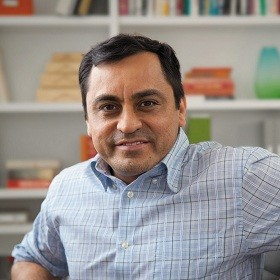

In [ ]:
image = await graph_client.me.photo.content.get()
from IPython.display import Image
Image(data=image)

In [ ]:
from rich import print
result = await graph_client.me.get()
print(result)

User(
    additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#users/$entity'},
    id='ab84db4f-eedd-4741-917b-38de513c3218',
    odata_type='#microsoft.graph.user',
    deleted_date_time=None,
    about_me=None,
    account_enabled=None,
    activities=None,
    age_group=None,
    agreement_acceptances=None,
    app_role_assignments=None,
    assigned_licenses=None,
    assigned_plans=None,
    authentication=None,
    authorization_info=None,
    birthday=None,
    business_phones=['+1 205 555 0108'],
    calendar=None,
    calendar_groups=None,
    calendar_view=None,
    calendars=None,
    chats=None,
    city=None,
    cloud_clipboard=None,
    company_name=None,
    consent_provided_for_minor=None,
    contact_folders=None,
    contacts=None,
    country=None,
    created_date_time=None,
    created_objects=None,
    creation_type=None,
    custom_security_attributes=None,
    department=None,
    device_enrollment_limit=None,
    device_management_troubleshooting_events=None,
    direct_reports=None,
    display_name='Diego Siciliani',
    drive=None,
    drives=None,
    employee_experience=None,
    employee_hire_date=None,
    employee_id=None,
    employee_leave_date_time=None,
    employee_org_data=None,
    employee_type=None,
    events=None,
    extensions=None,
    external_user_state=None,
    external_user_state_change_date_time=None,
    fax_number=None,
    followed_sites=None,
    given_name='Diego',
    hire_date=None,
    identities=None,
    im_addresses=None,
    inference_classification=None,
    insights=None,
    interests=None,
    is_management_restricted=None,
    is_resource_account=None,
    job_title='HR Manager',
    joined_teams=None,
    last_password_change_date_time=None,
    legal_age_group_classification=None,
    license_assignment_states=None,
    license_details=None,
    mail='DiegoS@mn3q.onmicrosoft.com',
    mail_folders=None,
    mail_nickname=None,
    mailbox_settings=None,
    managed_app_registrations=None,
    managed_devices=None,
    manager=None,
    member_of=None,
    messages=None,
    mobile_phone=None,
    my_site=None,
    oauth2_permission_grants=None,
    office_location='14/1108',
    on_premises_distinguished_name=None,
    on_premises_domain_name=None,
    on_premises_extension_attributes=None,
    on_premises_immutable_id=None,
    on_premises_last_sync_date_time=None,
    on_premises_provisioning_errors=None,
    on_premises_sam_account_name=None,
    on_premises_security_identifier=None,
    on_premises_sync_enabled=None,
    on_premises_user_principal_name=None,
    onenote=None,
    online_meetings=None,
    other_mails=None,
    outlook=None,
    owned_devices=None,
    owned_objects=None,
    password_policies=None,
    password_profile=None,
    past_projects=None,
    people=None,
    permission_grants=None,
    photo=None,
    photos=None,
    planner=None,
    postal_code=None,
    preferred_data_location=None,
    preferred_language='en-US',
    preferred_name=None,
    presence=None,
    print=None,
    provisioned_plans=None,
    proxy_addresses=None,
    registered_devices=None,
    responsibilities=None,
    schools=None,
    scoped_role_member_of=None,
    security_identifier=None,
    service_provisioning_errors=None,
    settings=None,
    show_in_address_list=None,
    sign_in_activity=None,
    sign_in_sessions_valid_from_date_time=None,
    skills=None,
    solutions=None,
    sponsors=None,
    state=None,
    street_address=None,
    surname='Siciliani',
    teamwork=None,
    todo=None,
    transitive_member_of=None,
    usage_location=None,
    user_principal_name='DiegoS@mn3q.onmicrosoft.com',
    user_type=None
)

In [ ]:
# my emails
from datetime import datetime, timedelta, timezone
from msgraph.generated.users.item.messages.messages_request_builder import MessagesRequestBuilder
from kiota_abstractions.base_request_configuration import RequestConfiguration

five_days_ago = datetime.now(timezone.utc) - timedelta(days=5)
five_days_ago_iso = five_days_ago.isoformat()
query_params = MessagesRequestBuilder.MessagesRequestBuilderGetQueryParameters(
		select = [
            "sender",
            "subject",
            "bodyPreview",
            "body",
            "createdDateTime",
            "receivedDateTime",
            "sentDateTime",
            # "odataCount"
            ],
		top = 15,
    filter=f"receivedDateTime ge {five_days_ago_iso}"

)

request_configuration = RequestConfiguration(query_parameters = query_params,
)
result = await graph_client.me.messages.get(request_configuration=request_configuration)
print(type(result))
print(result)
# print(len(result.value))
for message in result.value:
    print("subject", message.subject)
    print("sender", message.sender.email_address.address, "sender's name:",message.sender.email_address.name)
    # print("body.content:")
    # print(message.body.content)
    print("bodyPreview", message.body_preview)
    print("-"*100)

<class 'msgraph.generated.models.message_collection_response.MessageCollectionResponse'>

MessageCollectionResponse(
    additional_data={
        '@odata.context': 
"https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/messages(sender,subject,b
odyPreview,body,createdDateTime,receivedDateTime,sentDateTime)"
    },
    odata_count=None,
    odata_next_link=None,
    value=[
        Message(
            additional_data={'@odata.etag': 'W/"CQAAABYAAAAKqeojM2HeQJFNQeUszRwWAAApDAx4"'},
            id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJF
NQeUszRwWAAAAAAEJAAAKqeojM2HeQJFNQeUszRwWAAApEGsDAAA=',
            odata_type='#microsoft.graph.message',
            categories=None,
            change_key=None,
            created_date_time=datetime.datetime(2025, 4, 16, 15, 25, 11, tzinfo=datetime.timezone.utc),
            last_modified_date_time=None,
            attachments=None,
            bcc_recipients=None,
            body=ItemBody(
                additional_data={},
                content='<html><head>\r\n<meta http-equiv="Content-Type" content="text/html; charset=utf-8"><style 
type="text/css" 
style="display:none">\r\n<!--\r\np\r\n\t{margin-top:0;\r\n\tmargin-bottom:0}\r\n-->\r\n</style></head><body 
dir="ltr"><div style="font-family:Aptos,Aptos_EmbeddedFont,Aptos_MSFontService,Calibri,Helvetica,sans-serif; 
font-size:12pt; color:rgb(0,0,0)"></div><div 
style="font-family:Aptos,Aptos_EmbeddedFont,Aptos_MSFontService,Calibri,Helvetica,sans-serif; font-size:12pt; 
color:rgb(0,0,0)"><br></div><div id="appendonsend"></div><hr tabindex="-1" style="display:inline-block; 
width:98%"><div id="divRplyFwdMsg" dir="ltr"><font face="Calibri, sans-serif" color="#000000" 
style="font-size:11pt"><b>From:</b> Azure DevOps &lt;azuredevops@microsoft.com&gt;<br><b>Sent:</b> Monday, April 7,
2025 6:19 PM<br><b>To:</b> Diego Siciliani &lt;DiegoS@mn3q.onmicrosoft.com&gt;<br><b>Subject:</b> PR - [Epic 9] Add
environment configuration files for A... - agentictime 1 (Diego Siciliani)</font> 
<div>&nbsp;</div></div><style>\r\n<!--\r\nimg\r\n\t{border:0;\r\n\theight:auto;\r\n\tline-height:100%;\r\n\toutline
:none;\r\n\ttext-decoration:none}\r\ntable\r\n\t{border-collapse:collapse!important}\r\na[x-apple-data-detectors]\r
\n\t{color:inherit!important;\r\n\ttext-decoration:none!important;\r\n\tfont-size:inherit!important;\r\n\tfont-fami
ly:inherit!important;\r\n\tfont-weight:inherit!important;\r\n\tline-height:inherit!important}\r\ndiv\r\n\t{height:1
00%!important;\r\n\tmargin:0!important;\r\n\tpadding:0!important;\r\n\twidth:100%!important;\r\n\tbackground:white}
\r\nh1, h2, h3, h4, table, td, th, a, p, span, div, i, em, li, ul, .x_img-block, img, 
.x_comment\r\n\t{font-family:\'Segoe 
UI\',\'-apple-system\',\'BlinkMacSystemFont\',\'Roboto\',\'Arial\',sans-serif}\r\ntd\r\n\t{font-size:14px;\r\n\tlin
e-height:20px;\r\n\tcolor:#212121}\r\na\r\n\t{text-decoration:none;\r\n\tcolor:#0078D4}\r\nem\r\n\t{font-style:norm
al;\r\n\tcolor:#666}\r\np\r\n\t{margin:0}\r\n.x_img-block\r\n\t{display:block;\r\n\tcolor:#ccc;\r\n\tfont-size:10px
;\r\n\tmax-width:100%}\r\n.x_img-padding\r\n\t{padding:0 20px 0 
0}\r\n.x_comment\r\n\t{color:#333333;\r\n\tfont-size:14px;\r\n\tborder-radius:5px}\r\n.x_comment 
blockquote\r\n\t{color:#666666;\r\n\tborder-left:3px solid #a6a6a6;\r\n\tpadding:1px 0 1px 15px;\r\n\tmargin:12px 
0}\r\n.x_comment-gfx\r\n\t{padding-top:20px}\r\n.x_note\r\n\t{font-size:13px}\r\n.x_activity-table\r\n\t{display:ta
ble}\r\n.x_active\r\n\t{background:#CEF1DE;\r\n\tfont-family:\'Segoe 
UI\',\'-apple-system\',\'BlinkMacSystemFont\',\'Roboto\',\'Arial\',sans-serif;\r\n\tfont-size:14px;\r\n\tcolor:#333
333;\r\n\tpadding:2px 
4px;\r\n\tdisplay:inline-block}\r\n.x_inactive\r\n\t{background:#eeeeee;\r\n\tfont-family:\'Segoe 
UI\',\'-apple-system\',\'BlinkMacSystemFont\',\'Roboto\',\'Arial\',sans-serif;\r\n\tfont-size:14px;\r\n\ttext-decor
ation:line-through;\r\n\tcolor:#666666;\r\n\tpadding:2px 
4px;\r\n\tdisplay:inline-block}\r\n.x_row-label\r\n\t{font-fa

subject Test Fw: PR - [Epic 9] Add environment configuration files for A... - agentictime 1 (Diego Siciliani)

sender DiegoS@mn3q.onmicrosoft.com sender's name: Diego Siciliani

bodyPreview ________________________________
From: Azure DevOps <azuredevops@microsoft.com>
Sent: Monday, April 7, 2025 6:19 PM
To: Diego Siciliani <DiegoS@mn3q.onmicrosoft.com>
Subject: PR - [Epic 9] Add environment configuration files for A... - agentictime 1

----------------------------------------------------------------------------------------------------

subject Test Fw: PR - [Epic 9] Add environment configuration files for A... - agentictime 1 (Diego Siciliani)

sender DiegoS@mn3q.onmicrosoft.com sender's name: Diego Siciliani

bodyPreview ________________________________
From: Azure DevOps <azuredevops@microsoft.com>
Sent: Monday, April 7, 2025 6:19 PM
To: Diego Siciliani <DiegoS@mn3q.onmicrosoft.com>
Subject: PR - [Epic 9] Add environment configuration files for A... - agentictime 1

----------------------------------------------------------------------------------------------------

In [ ]:
from typing import List, Optional, Dict
from pydantic import BaseModel
from msgraph.generated.models.message_collection_response import MessageCollectionResponse
from datetime import date, datetime, time, timedelta

class EmailAddress(BaseModel):
    address: Optional[str]
    name: Optional[str]
    odata_type: Optional[str] = None


class Message(BaseModel):
    id: Optional[str]
    odata_type: Optional[str] = None
    subject: Optional[str] = None
    sender: Optional[EmailAddress] = None
    body_preview: Optional[str] = None

    created_date_time: Optional[datetime] = None
    sent_date_time: Optional[datetime] = None
    received_date_time: Optional[datetime] = None
    last_modified_date_time: Optional[datetime] = None

class MessageCollectionResult(BaseModel):
    emails: List[Message]
    odata_count: Optional[int] = None
    odata_next_link: Optional[str] = None

def mapping_emails(client_result: MessageCollectionResponse) -> MessageCollectionResult:
    emails = [
        Message(
            id=email.id,
            subject=email.subject,
            sender=EmailAddress(
                address=email.sender.email_address.address,
                name=email.sender.email_address.name,
            ),
            body_preview=email.body_preview,
            created_date_time=email.created_date_time,
            sent_date_time=email.sent_date_time,
            received_date_time=email.received_date_time,
            last_modified_date_time=email.last_modified_date_time,
        )
        for email in client_result.value
    ]
    return MessageCollectionResult(
        emails=emails,
    )
rprint(mapping_emails(result))

MessageCollectionResult(
    emails=[
        Message(
            id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJF
NQeUszRwWAAAAAAEJAAAKqeojM2HeQJFNQeUszRwWAAApEGsDAAA=',
            odata_type=None,
            subject='Test Fw: PR - [Epic 9] Add environment configuration files for A... - agentictime 1 (Diego 
Siciliani)',
            sender=EmailAddress(address='DiegoS@mn3q.onmicrosoft.com', name='Diego Siciliani', odata_type=None),
            body_preview='________________________________\r\nFrom: Azure DevOps 
<azuredevops@microsoft.com>\r\nSent: Monday, April 7, 2025 6:19 PM\r\nTo: Diego Siciliani 
<DiegoS@mn3q.onmicrosoft.com>\r\nSubject: PR - [Epic 9] Add environment configuration files for A... - agentictime 
1',
            created_date_time=datetime.datetime(2025, 4, 16, 15, 25, 11, tzinfo=datetime.timezone.utc),
            sent_date_time=datetime.datetime(2025, 4, 16, 15, 25, 29, tzinfo=datetime.timezone.utc),
            received_date_time=datetime.datetime(2025, 4, 16, 15, 25, 32, tzinfo=datetime.timezone.utc),
            last_modified_date_time=None
        ),
        Message(
            id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJF
NQeUszRwWAAAAAAEMAAAKqeojM2HeQJFNQeUszRwWAAApEHLWAAA=',
            odata_type=None,
            subject='Test Fw: PR - [Epic 9] Add environment configuration files for A... - agentictime 1 (Diego 
Siciliani)',
            sender=EmailAddress(address='DiegoS@mn3q.onmicrosoft.com', name='Diego Siciliani', odata_type=None),
            body_preview='________________________________\r\nFrom: Azure DevOps 
<azuredevops@microsoft.com>\r\nSent: Monday, April 7, 2025 6:19 PM\r\nTo: Diego Siciliani 
<DiegoS@mn3q.onmicrosoft.com>\r\nSubject: PR - [Epic 9] Add environment configuration files for A... - agentictime 
1',
            created_date_time=datetime.datetime(2025, 4, 16, 15, 25, 35, tzinfo=datetime.timezone.utc),
            sent_date_time=datetime.datetime(2025, 4, 16, 15, 25, 29, tzinfo=datetime.timezone.utc),
            received_date_time=datetime.datetime(2025, 4, 16, 15, 25, 35, tzinfo=datetime.timezone.utc),
            last_modified_date_time=None
        )
    ],
    odata_count=None,
    odata_next_link=None
)

In [ ]:
result = await graph_client.me.drive.get()
result

Drive(additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#drives/$entity'}, id='b!ica54BfvI0usSub3K7_hbAGzk2-DQ1xJul6J__HCkVsLMCZjbx-WQq0PSt5UJ0_y', odata_type='#microsoft.graph.drive', created_by=IdentitySet(additional_data={}, application=None, device=None, odata_type=None, user=Identity(additional_data={}, display_name='System Account', id=None, odata_type=None)), created_by_user=None, created_date_time=datetime.datetime(2025, 2, 9, 6, 45, 48, tzinfo=datetime.timezone.utc), description='', e_tag=None, last_modified_by=IdentitySet(additional_data={}, application=None, device=None, odata_type=None, user=Identity(additional_data={}, display_name='System Account', id=None, odata_type=None)), last_modified_by_user=None, last_modified_date_time=datetime.datetime(2025, 4, 3, 18, 18, 47, tzinfo=datetime.timezone.utc), name='OneDrive', parent_reference=None, web_url='https://mn3q-my.sharepoint.com/personal/diegos_mn3q_onmicrosoft_com/Documents', bundles=None, drive

In [ ]:
result = await graph_client.drives.by_drive_id('b!ica54BfvI0usSub3K7_hbAGzk2-DQ1xJul6J__HCkVsLMCZjbx-WQq0PSt5UJ0_y').get()
print(result)
drive_id = result.id

Drive(
    additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#drives/$entity'},
    id='b!ica54BfvI0usSub3K7_hbAGzk2-DQ1xJul6J__HCkVsLMCZjbx-WQq0PSt5UJ0_y',
    odata_type='#microsoft.graph.drive',
    created_by=IdentitySet(
        additional_data={},
        application=None,
        device=None,
        odata_type=None,
        user=Identity(additional_data={}, display_name='System Account', id=None, odata_type=None)
    ),
    created_by_user=None,
    created_date_time=datetime.datetime(2025, 2, 9, 6, 45, 48, tzinfo=datetime.timezone.utc),
    description='',
    e_tag=None,
    last_modified_by=IdentitySet(
        additional_data={},
        application=None,
        device=None,
        odata_type=None,
        user=Identity(additional_data={}, display_name='System Account', id=None, odata_type=None)
    ),
    last_modified_by_user=None,
    last_modified_date_time=datetime.datetime(2025, 4, 3, 18, 18, 47, tzinfo=datetime.timezone.utc),
    name='OneDrive',
    parent_reference=None,
    web_url='https://mn3q-my.sharepoint.com/personal/diegos_mn3q_onmicrosoft_com/Documents',
    bundles=None,
    drive_type='business',
    following=None,
    items=None,
    list_=None,
    owner=IdentitySet(
        additional_data={},
        application=None,
        device=None,
        odata_type=None,
        user=Identity(
            additional_data={'email': 'DiegoS@mn3q.onmicrosoft.com'},
            display_name='Diego Siciliani',
            id='ab84db4f-eedd-4741-917b-38de513c3218',
            odata_type=None
        )
    ),
    quota=Quota(
        additional_data={},
        deleted=0,
        odata_type=None,
        remaining=1099509169229,
        state='normal',
        storage_plan_information=None,
        total=1099511627776,
        used=2458547
    ),
    root=None,
    share_point_ids=None,
    special=None,
    system=None
)

In [ ]:
# Get items in the root of the drive
items = await graph_client.drives.by_drive_id(drive_id).items.by_drive_item_id('root').children.get()
if items and items.value:
    for item in items.value:
        print(f"ID: {item.id}, Name: {item.name}, Type: {'Folder' if item.folder else 'File'}")
        print("url:",item.web_url)
        print("created by:",item.created_by)
        print("file system info:",item.file_system_info)
        print("size:",item.size)
        print("parent reference:",item.parent_reference)
        print(item.c_tag)
        # print(dir(item))

ID: 01WCLFHUMZ4NXWQ2DDWNBKOBP7VGOFPVDU, Name: candy.JPG, Type: File

url: https://mn3q-my.sharepoint.com/personal/diegos_mn3q_onmicrosoft_com/Documents/candy.JPG

created by:
IdentitySet(
    additional_data={},
    application=Identity(
        additional_data={},
        display_name='SharePoint Online Client Extensibility',
        id='c58637bb-e2e1-4312-8a00-04b5ffcd3403',
        odata_type=None
    ),
    device=None,
    odata_type=None,
    user=Identity(
        additional_data={'email': 'DiegoS@mn3q.onmicrosoft.com'},
        display_name='Diego Siciliani',
        id='ab84db4f-eedd-4741-917b-38de513c3218',
        odata_type=None
    )
)

file system info:
FileSystemInfo(
    additional_data={},
    created_date_time=datetime.datetime(2025, 4, 3, 18, 18, 47, tzinfo=datetime.timezone.utc),
    last_accessed_date_time=None,
    last_modified_date_time=datetime.datetime(2025, 4, 3, 18, 18, 47, tzinfo=datetime.timezone.utc),
    odata_type=None
)

size: 2289891

parent reference:
ItemReference(
    additional_data={},
    drive_id='b!ica54BfvI0usSub3K7_hbAGzk2-DQ1xJul6J__HCkVsLMCZjbx-WQq0PSt5UJ0_y',
    drive_type='business',
    id='01WCLFHUN6Y2GOVW7725BZO354PWSELRRZ',
    name='Documents',
    odata_type=None,
    path='/drives/b!ica54BfvI0usSub3K7_hbAGzk2-DQ1xJul6J__HCkVsLMCZjbx-WQq0PSt5UJ0_y/root:',
    share_id=None,
    sharepoint_ids=None,
    site_id='e0b9c689-ef17-4b23-ac4a-e6f72bbfe16c'
)

"c:{686FE399-6368-42B3-A705-FFA99C57D474},1"

In [ ]:
# scopes = ['https://graph.microsoft.com/.default']
scopes =['Sites.Read.All']
graph_client = GraphServiceClient(credentials=credentials, scopes=scopes)
result = await graph_client.me.insights.trending.get()
result

TrendingCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/insights/trending"}, odata_count=None, odata_next_link=None, value=[])

In [ ]:
scopes = ['Calendars.ReadWrite']
graph_client = GraphServiceClient(credentials=credentials, scopes=scopes)
result = await graph_client.me.calendars.get()
result

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code ETDUU3DM3 to authenticate.


CalendarCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendars"}, odata_count=None, odata_next_link=None, value=[Calendar(additional_data={}, id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAbkYL4AAA=', odata_type=None, allowed_online_meeting_providers=[<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>], calendar_permissions=None, calendar_view=None, can_edit=True, can_share=True, can_view_private_items=True, change_key='CqnqIzNh3kCRTUHlLM0cFgAAG5EvSw==', color=<CalendarColor.Auto: 'auto'>, default_online_meeting_provider=<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>, events=None, hex_color='', is_default_calendar=True, is_removable=False, is_tallying_responses=True, multi_value_extended_properties=None, name='Calendar', owner=EmailAddress(additional_data={},

In [ ]:
from msgraph.generated.models.calendar import Calendar
request_body = Calendar(
	name = "Family Calendar",
)

result = await graph_client.me.calendars.post(request_body)
result

Calendar(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendars/$entity"}, id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAgRU_LAAA=', odata_type=None, allowed_online_meeting_providers=[<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>], calendar_permissions=None, calendar_view=None, can_edit=True, can_share=True, can_view_private_items=True, change_key='CqnqIzNh3kCRTUHlLM0cFgAAIELwIA==', color=<CalendarColor.Auto: 'auto'>, default_online_meeting_provider=<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>, events=None, hex_color='', is_default_calendar=False, is_removable=True, is_tallying_responses=False, multi_value_extended_properties=None, name='Family Calendar', owner=EmailAddress(additional_data={}, address='DiegoS@mn3q.onmicrosoft.com', name='Diego Siciliani', odata_type=Non

In [ ]:
family_calendar = await graph_client.me.calendars.by_calendar_id('AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAgRU_LAAA=').get()
family_calendar

Calendar(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendars/$entity"}, id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAgRU_LAAA=', odata_type=None, allowed_online_meeting_providers=[<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>], calendar_permissions=None, calendar_view=None, can_edit=True, can_share=True, can_view_private_items=True, change_key='CqnqIzNh3kCRTUHlLM0cFgAAIELwIA==', color=<CalendarColor.Auto: 'auto'>, default_online_meeting_provider=<OnlineMeetingProviderType.TeamsForBusiness: 'teamsForBusiness'>, events=None, hex_color='', is_default_calendar=False, is_removable=True, is_tallying_responses=False, multi_value_extended_properties=None, name='Family Calendar', owner=EmailAddress(additional_data={}, address='DiegoS@mn3q.onmicrosoft.com', name='Diego Siciliani', odata_type=Non

In [ ]:
my_calendar = await graph_client.me.calendars.get()
for calendar in my_calendar.value:
    if calendar.name == "Family Calendar":
        family_calendar = calendar
        family_calendar_id = calendar.id
    print(f"ID: {calendar.id}")
    print(f"Name: {calendar.name}")
    print(f"Owner: {calendar.owner.name} ({calendar.owner.address})")
    print(f"Can Edit: {calendar.can_edit}")
    print(f"Can Share: {calendar.can_share}")
    print(f"Is Default Calendar: {calendar.is_default_calendar}")
    print(f"Allowed Online Meeting Providers: {', '.join(provider.name for provider in calendar.allowed_online_meeting_providers)}")
    print("-" * 40)  # Separator for better readability

ID: AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAbkYL4AAA=
Name: Calendar
Owner: Diego Siciliani (DiegoS@mn3q.onmicrosoft.com)
Can Edit: True
Can Share: True
Is Default Calendar: True
Allowed Online Meeting Providers: TeamsForBusiness
----------------------------------------
ID: AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAbkYL5AAA=
Name: United States holidays
Owner: Diego Siciliani (DiegoS@mn3q.onmicrosoft.com)
Can Edit: False
Can Share: False
Is Default Calendar: False
Allowed Online Meeting Providers: 
----------------------------------------
ID: AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAbkYL8AAA=
Name: Birthdays
Owner: Diego Siciliani (DiegoS@mn3q.onmicrosoft.com)
Can Edit: False
Can Share

In [ ]:
result = await  graph_client.me.calendar.allowed_calendar_sharing_roles_with_user(user='DiegoS@mn3q.onmicrosoft.com').get()
result

AllowedCalendarSharingRolesWithUserGetResponse(additional_data={'@odata.context': 'https://graph.microsoft.com/v1.0/$metadata#Collection(microsoft.graph.calendarRoleType)'}, odata_count=None, odata_next_link=None, value=[])

In [ ]:
# Code snippets are only available for the latest version. Current version is 1.x
from msgraph import GraphServiceClient
from msgraph.generated.users.item.calendar.calendar_view.calendar_view_request_builder import CalendarViewRequestBuilder
from kiota_abstractions.base_request_configuration import RequestConfiguration
# To initialize your graph_client, see https://learn.microsoft.com/en-us/graph/sdks/create-client?from=snippets&tabs=python
query_params = CalendarViewRequestBuilder.CalendarViewRequestBuilderGetQueryParameters(
		start_date_time = "2025-04-01T19:00:00-08:00",
		end_date_time = "2025-04-07T19:00:00-08:00",
)

request_configuration = RequestConfiguration(
query_parameters = query_params,
)

result = await graph_client.me.calendar.calendar_view.get(request_configuration = request_configuration)
result

EventCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendar/calendarView"}, odata_count=None, odata_next_link=None, value=[])

In [ ]:
result = await graph_client.me.calendar.events.get()
result

EventCollectionResponse(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendar/events"}, odata_count=None, odata_next_link=None, value=[])

In [ ]:
# Code snippets are only available for the latest version. Current version is 1.x
from msgraph import GraphServiceClient
from msgraph.generated.models.event import Event
from msgraph.generated.models.item_body import ItemBody
from msgraph.generated.models.body_type import BodyType
from msgraph.generated.models.date_time_time_zone import DateTimeTimeZone
from msgraph.generated.models.location import Location
from msgraph.generated.models.attendee import Attendee
from msgraph.generated.models.email_address import EmailAddress
from msgraph.generated.models.attendee_type import AttendeeType

# To initialize your graph_client, see https://learn.microsoft.com/en-us/graph/sdks/create-client?from=snippets&tabs=python
request_body = Event(
    subject="GenAI Team Meeting: Agentic AI Discussion",
    body=ItemBody(
        content_type=BodyType.Html,
        content="Join us for a discussion on Agentic AI. Looking forward to your insights!",
    ),
    start=DateTimeTimeZone(
        date_time="2025-04-04T10:00:00",  # Updated to the desired date and time
        time_zone="Pacific Standard Time",  # Adjust time zone if necessary
    ),
    end=DateTimeTimeZone(
        date_time="2025-04-04T11:00:00",  # Updated to one hour later
        time_zone="Pacific Standard Time",  # Adjust time zone if necessary
    ),
    location=Location(
        display_name="Virtual Meeting Room",  # Updated location description
    ),
    attendees=[
        Attendee(
            email_address=EmailAddress(
                address="DiegoS@mn3q.onmicrosoft.com",
                name="Adele Vance",
            ),
            type=AttendeeType.Required,
        ),
        # Add more attendees as needed
    ],
    transaction_id="7E163156-0001-4BEB-A1C6-729EA81755A7",
)

result = await graph_client.me.calendars.by_calendar_id(family_calendar_id).events.post(request_body)
result

Event(additional_data={'@odata.context': "https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendars('AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAgRU_LAAA%3D')/events/$entity", '@odata.etag': 'W/"CqnqIzNh3kCRTUHlLM0cFgAAIELxBQ=="', 'uid': '040000008200E00074C5B7101A82E00800000000297F6B3AD3A4DB0100000000000000001000000071A8B7F92B175644BE02795EC8C96317', 'occurrenceId': None}, id='AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAgRRjCAAAKqeojM2HeQJFNQeUszRwWAAAgRVdiAAA=', odata_type='#microsoft.graph.event', categories=[], change_key='CqnqIzNh3kCRTUHlLM0cFgAAIELxBQ==', created_date_time=datetime.datetime(2025, 4, 3, 20, 1, 46, 271522, tzinfo=datetime.timezone.utc), last_modified_date_time=datetime.datetime(2025, 4, 3, 20, 1, 46, 348345, tzinfo=datetime.timezone.utc), allow_new_time_proposal

In [ ]:

graph_client = GraphServiceClient(credentials=credentials, scopes=scopes)
# result = await graph_client.me.manager.get()
# result

In [ ]:
# result = await graph_client.me.todo.lists.get()
# result

To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code BCUC84CA3 to authenticate.


In [ ]:
from msgraph import GraphServiceClient
from msgraph.generated.users.item.events.events_request_builder import EventsRequestBuilder
from kiota_abstractions.base_request_configuration import RequestConfiguration
query_params = EventsRequestBuilder.EventsRequestBuilderGetQueryParameters(
		select = ["subject","body","bodyPreview","organizer","attendees","start","end","location"],
)

request_configuration = RequestConfiguration(
query_parameters = query_params,
)

result = await graph_client.me.calendars.by_calendar_id(family_calendar_id).events.get(request_configuration = request_configuration)
# Assuming event_collection_response contains the EventCollectionResponse object as described

# Extracting and printing event details
print("# Event Collection Response")
print(f"## Context")
print(f"- **@odata.context**: {result.additional_data['@odata.context']}")

print("\n## Events")
for index, event in enumerate(result.value, start=1):
    print(f"\n### Event {index}")
    print(f"- **ID**: {event.id}")
    print(f"- **Subject**: {event.subject}")
    print(f"- **Body Preview**: {event.body_preview}")
    print(f"- **Organizer**: {event.organizer.email_address.name} ({event.organizer.email_address.address})")
    print(f"- **Start Time**: {event.start.date_time} (Time Zone: {event.start.time_zone})")
    print(f"- **End Time**: {event.end.date_time} (Time Zone: {event.end.time_zone})")
    print(f"- **Location**: {event.location.display_name}")

    if event.attendees:
        print("- **Attendees**:")
        for attendee in event.attendees:
            print(f"  - {attendee.email_address.name} ({attendee.email_address.address}) - Status: {attendee.status.response}")

    print("-" * 40)  # Separator for better readability

# Event Collection Response
## Context
- **@odata.context**: https://graph.microsoft.com/v1.0/$metadata#users('ab84db4f-eedd-4741-917b-38de513c3218')/calendars('AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAAAAEGAAAKqeojM2HeQJFNQeUszRwWAAAgRU_LAAA%3D')/events(subject,body,bodyPreview,organizer,attendees,start,end,location)

## Events

### Event 1
- **ID**: AAMkADYyMmQ5YTY1LTQ0NDgtNGRhZi04YmE4LTBiOTdmYWRlMjMyNABGAAAAAABesOyeThmVT6Uc65eW7diyBwAKqeojM2HeQJFNQeUszRwWAAAgRRjCAAAKqeojM2HeQJFNQeUszRwWAAAgRVdiAAA=
- **Subject**: GenAI Team Meeting: Agentic AI Discussion
- **Body Preview**: Join us for a discussion on Agentic AI. Looking forward to your insights!
- **Organizer**: Diego Siciliani (DiegoS@mn3q.onmicrosoft.com)
- **Start Time**: 2025-04-04T17:00:00.0000000 (Time Zone: UTC)
- **End Time**: 2025-04-04T18:00:00.0000000 (Time Zone: UTC)
- **Location**: Virtual Meeting Room
- **Attendees**:
  - Diego Siciliani (DiegoS@mn3

In [ ]:
result = await graph_client.me.contacts.get()
result

ODataError: 
        APIError
        Code: 403
        message: None
        error: MainError(additional_data={}, code='ErrorAccessDenied', details=None, inner_error=None, message='Access is denied. Check credentials and try again.', target=None)
        